In [2]:
# Heart Disease Prediction System - Data Analysis
# This notebook performs exploratory data analysis (EDA), visualization, 
# and evaluation of the Framingham dataset used for predicting 10-year 
# coronary heart disease risk.

In [6]:
import os

# Create folder to store images
os.makedirs("plots", exist_ok=True)

def save_plot(name):
    plt.savefig(f"plots/{name}.png", dpi=300, bbox_inches='tight')

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

sns.set(style="whitegrid")

In [10]:
import pandas as pd

df = pd.read_csv("/home/gowthami/Downloads/framingham.xls")
df.to_csv("/home/gowthami/Downloads/output.csv", index=False)

print(df)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

In [13]:
df = pd.read_csv("output.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


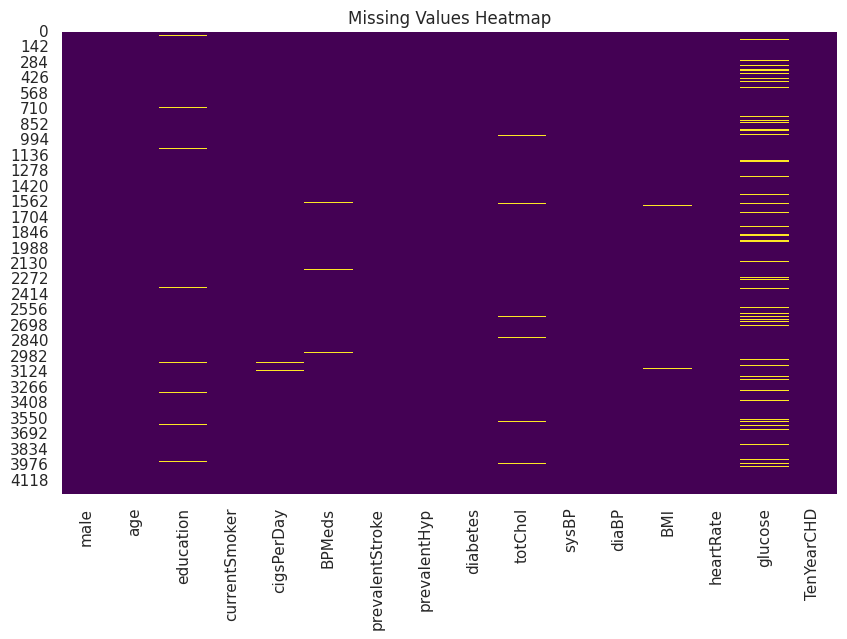

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
save_plot("missing_values_heatmap")
plt.show()

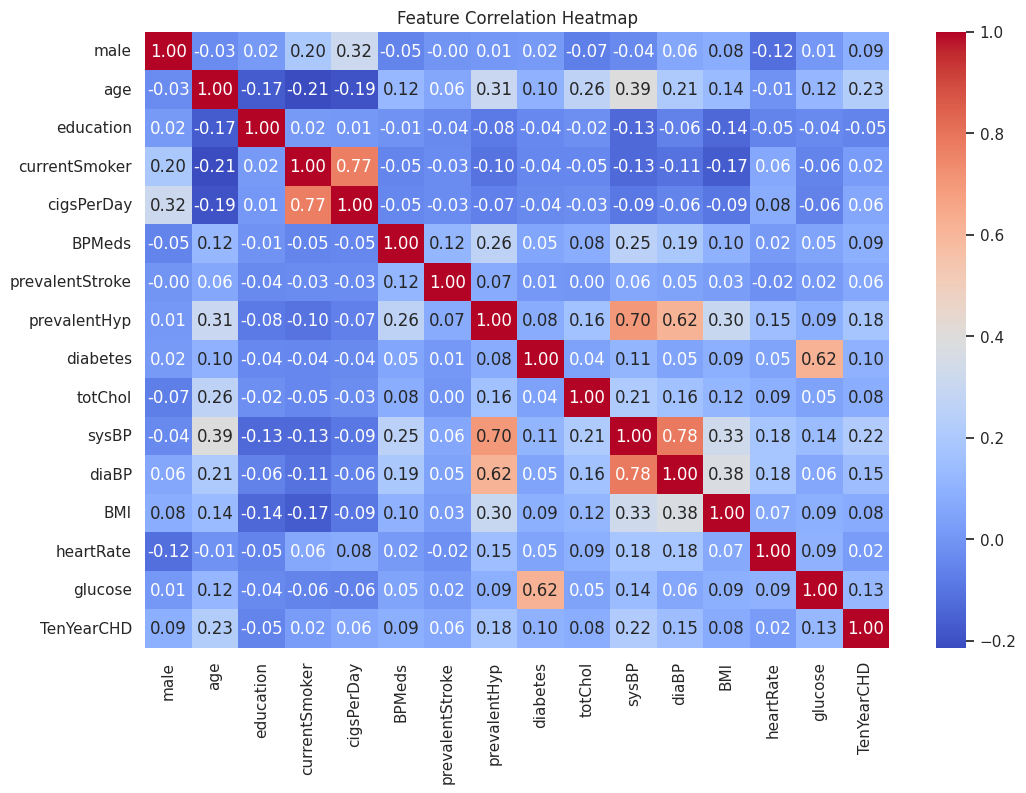

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
save_plot("correlation_heatmap")
plt.show()

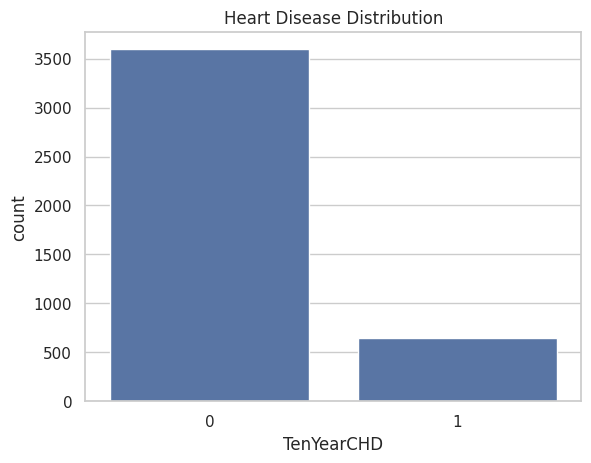

In [16]:
sns.countplot(x='TenYearCHD', data=df)
plt.title("Heart Disease Distribution")
save_plot("target_distribution")
plt.show()

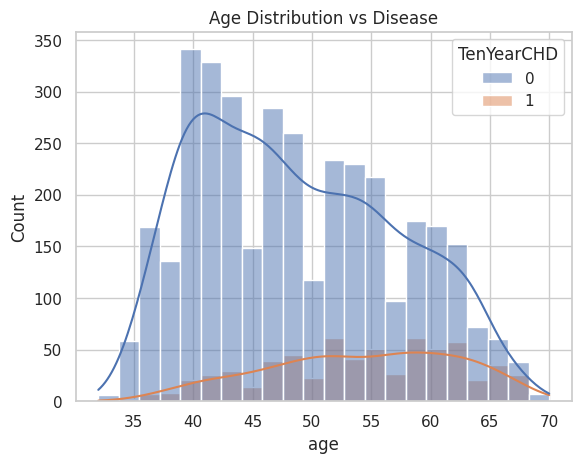

In [17]:
sns.histplot(data=df, x='age', hue='TenYearCHD', kde=True)
plt.title("Age Distribution vs Disease")
save_plot("age_vs_disease")
plt.show()

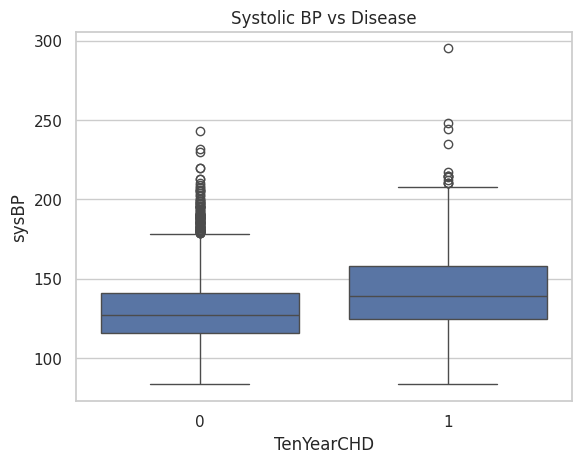

In [18]:
sns.boxplot(x='TenYearCHD', y='sysBP', data=df)
plt.title("Systolic BP vs Disease")
save_plot("bp_vs_disease")
plt.show()

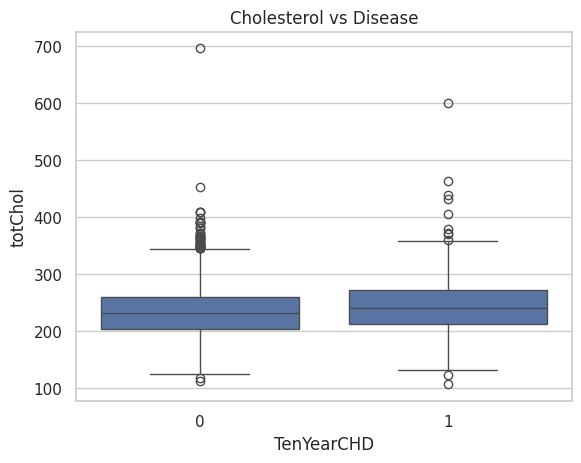

In [19]:
sns.boxplot(x='TenYearCHD', y='totChol', data=df)
plt.title("Cholesterol vs Disease")
save_plot("cholesterol_vs_disease")
plt.show()

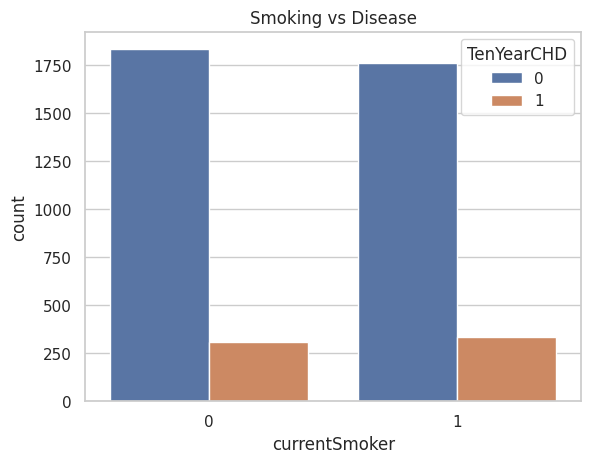

In [20]:
sns.countplot(x='currentSmoker', hue='TenYearCHD', data=df)
plt.title("Smoking vs Disease")
save_plot("smoking_vs_disease")
plt.show()

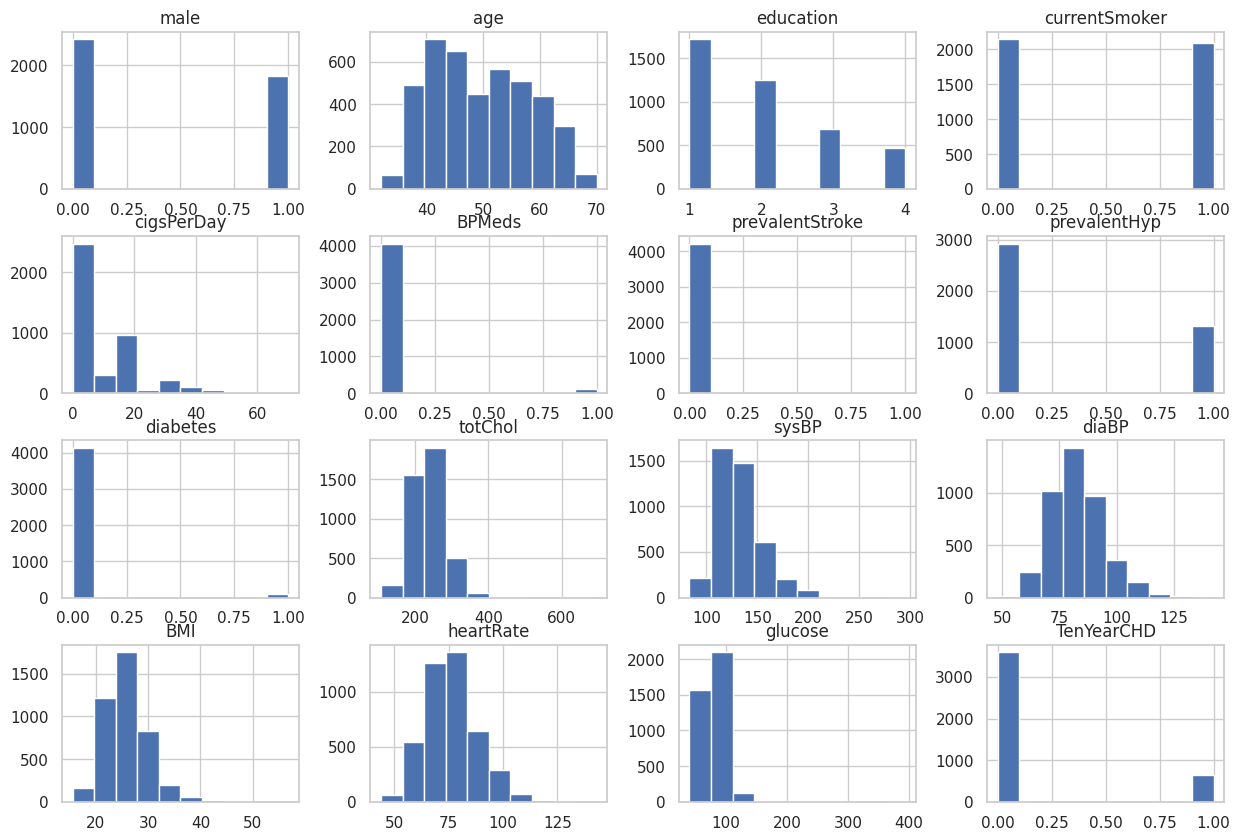

In [21]:
df.hist(figsize=(15,10))
save_plot("feature_distribution")
plt.show()

In [22]:
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'model.pkl'

In [ ]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

X_scaled = scaler.transform(X)

In [ ]:
y_pred = model.predict(X_scaled)
y_prob = model.predict_proba(X_scaled)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1 Score:", f1_score(y, y_pred))

In [ ]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
save_plot("confusion_matrix")
plt.show()

In [ ]:
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
save_plot("roc_curve")
plt.legend()
plt.show()

In [ ]:
if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_
    features = X.columns

    feat_df = pd.DataFrame({'Feature': features, 'Importance': importance})
    feat_df = feat_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feat_df)
    plt.title("Feature Importance")
    save_plot("feature_importance")
    plt.show()